# 04a - Clustering Model
Priprava dat, vyber optimalniho K, trenink dvou clustering algoritmu a PCA.

**Algoritmy:**
- **K-Means** — particni shlukování na zaklade centroidu; rychly, vyzaduje volbu K predem
- **Agglomerative Clustering** — hierarchicke shlukování (bottom-up); nevyzaduje K predem, ale K musime zvolit pro finalni rez dendrogramem; robustnejsi vuci tvaru shluku

Vystupy: `models/kmeans_final.pkl`, `models/agglomerative_final.pkl`, `models/pca_2d.pkl`, `data/processed/clustered_data.pkl`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


X_train_prep, X_test_prep, y_train, y_test = joblib.load('../data/processed/split_data.pkl')
X_all = pd.concat([X_train_prep, X_test_prep])
y_all = pd.concat([y_train, y_test])

# --- Podmnozina: pouze studenti v 1. semestru ---
# Zadani doporucuje shlukovat vybranou podskupinu, nikoliv cely dataset
mask  = X_all['Semester'] == 1
X_sub = X_all[mask].copy()
y_sub = y_all[mask].copy()
print(f"Cely dataset: {len(X_all)} radku")
print(f"Podmnozina (Semester==1): {len(X_sub)} radku  ({len(X_sub)/len(X_all):.1%} z celku)")

cols_for_clustering = ['Stress_Index', 'Study_Hours_per_Day', 'Family_Income', 'CGPA']
cols_for_clustering = [c for c in cols_for_clustering if c in X_sub.columns]
print(f"Priznaky pro clustering: {cols_for_clustering}")

# --- StandardScaler: normalizace pred shlukovanim ---
# Bez scalingu dominuji featury s velkou absolutni hodnotou (napr. Family_Income)
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_sub[cols_for_clustering])
X_cluster = pd.DataFrame(X_scaled, columns=cols_for_clustering, index=X_sub.index)
print("Data normalizovana pomoci StandardScaler (mean=0, std=1).")

import matplotlib as _mpl

# Paul Tol bright palette — colorblind-safe, perceptually uniform
_PALETTE = ['#0077BB', '#EE7733', '#009988', '#CC3311', '#33BBEE', '#EE3377', '#BBBBBB']

_mpl.rcParams.update({
    # Color cycle
    'axes.prop_cycle':       _mpl.cycler(color=_PALETTE),

    # Backgrounds
    'figure.facecolor':      'white',
    'axes.facecolor':        '#F8F9FA',   # subtle off-white — "card" feel

    # Spines
    'axes.edgecolor':        '#DEE2E6',
    'axes.linewidth':        0.9,
    'axes.spines.top':       False,
    'axes.spines.right':     False,

    # Grid — solid, very light
    'axes.grid':             True,
    'axes.axisbelow':        True,
    'grid.color':            '#E9ECEF',
    'grid.linestyle':        '-',
    'grid.linewidth':        0.8,
    'grid.alpha':            1.0,

    # Typography
    'font.family':           'sans-serif',
    'font.sans-serif':       ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'axes.titlesize':        14,
    'axes.titleweight':      'bold',
    'axes.titlepad':         14,
    'axes.labelsize':        12,
    'axes.labelweight':      'regular',
    'xtick.labelsize':       10,
    'ytick.labelsize':       10,
    'legend.fontsize':       10,
    'legend.title_fontsize': 11,
    'figure.titlesize':      16,
    'figure.titleweight':    'bold',

    # Text colors — near-black for contrast
    'text.color':            '#212529',
    'axes.labelcolor':       '#495057',
    'xtick.color':           '#495057',
    'ytick.color':           '#495057',

    # Ticks
    'xtick.direction':       'out',
    'ytick.direction':       'out',
    'xtick.major.size':      4,
    'ytick.major.size':      4,
    'xtick.minor.visible':   False,
    'ytick.minor.visible':   False,
    'xtick.major.pad':       5,
    'ytick.major.pad':       5,

    # Lines & markers
    'lines.linewidth':       2.0,
    'lines.markersize':      7,
    'patch.linewidth':       0.6,

    # Legend
    'legend.frameon':        True,
    'legend.framealpha':     0.92,
    'legend.edgecolor':      '#DEE2E6',
    'legend.fancybox':       True,
    'legend.borderpad':      0.6,

    # Figure / saving
    'figure.dpi':            100,
    'figure.figsize':        [8, 5],
    'savefig.dpi':           150,
    'savefig.bbox':          'tight',
    'savefig.facecolor':     'white',
    'savefig.edgecolor':     'none',
})


Cely dataset: 10000 radku
Podmnozina (Semester==1): 2455 radku  (24.6% z celku)
Priznaky pro clustering: ['Stress_Index', 'Study_Hours_per_Day', 'Family_Income', 'CGPA']
Data normalizovana pomoci StandardScaler (mean=0, std=1).


## Elbow Method
Hledame bod, kde pokles inertie zacina stagnovat.

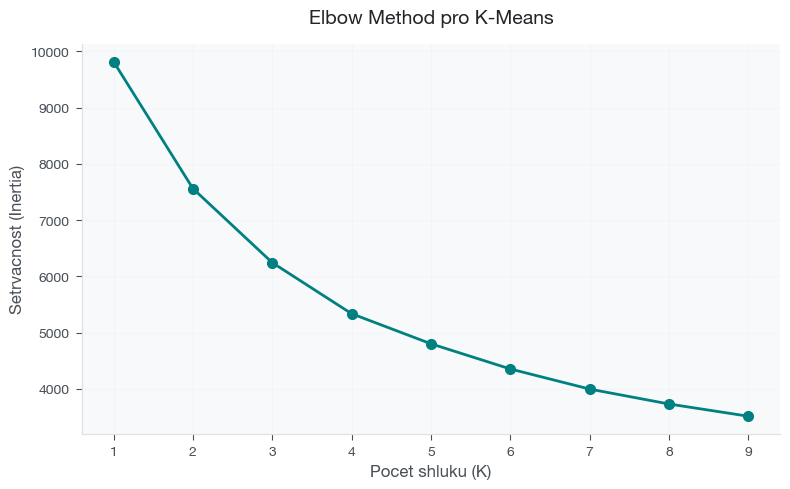

In [2]:
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='teal', linewidth=2)
plt.title('Elbow Method pro K-Means', fontsize=14, pad=15)
plt.xlabel('Pocet shluku (K)')
plt.ylabel('Setrvacnost (Inertia)')
plt.xticks(K_range)
plt.yticks()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Silhouette Score
Kvantitativni potvrzeni volby K — cim vyssi skore, tim lepe oddelene shluky. Mereno pro K=2..7.

--- Hledani optimalniho K pomoci Silhouette Score ---
  K=2  Silhouette: 0.227
  K=3  Silhouette: 0.242
  K=4  Silhouette: 0.223
  K=5  Silhouette: 0.189
  K=6  Silhouette: 0.198
  K=7  Silhouette: 0.202


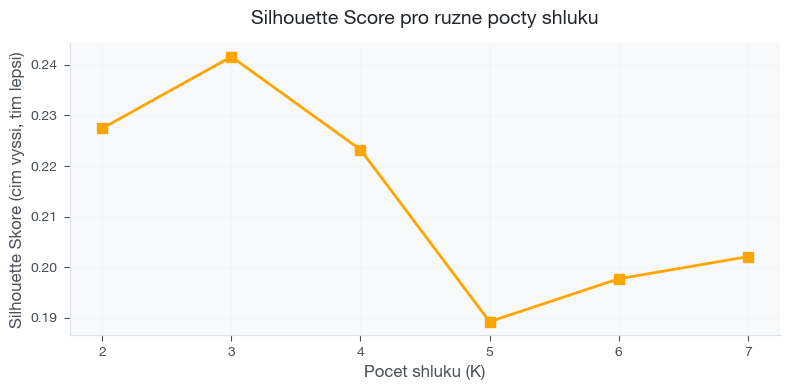


Nejlepsi K podle Silhouette: 3 (skore: 0.242)


In [3]:
print("--- Hledani optimalniho K pomoci Silhouette Score ---")
silhouette_scores = []
K_range_sil = range(2, 8)

for k in K_range_sil:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_temp.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, cluster_labels)
    silhouette_scores.append(score)
    print(f"  K={k}  Silhouette: {score:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(K_range_sil, silhouette_scores, marker='s', color='orange', linewidth=2)
plt.title('Silhouette Score pro ruzne pocty shluku', fontsize=14)
plt.xlabel('Pocet shluku (K)')
plt.ylabel('Silhouette Skore (cim vyssi, tim lepsi)')
plt.xticks(K_range_sil)
plt.yticks()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = list(K_range_sil)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nNejlepsi K podle Silhouette: {best_k} (skore: {max(silhouette_scores):.3f})")

## Trenink finálního modelu
Nastavte `OPTIMAL_K` na zaklade grafu vyse.

In [4]:
OPTIMAL_K = 3  # <-- upravte dle Elbow + Silhouette grafu

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
X_cluster['Cluster'] = kmeans_final.fit_predict(X_cluster)
X_cluster['Dropout'] = y_sub.values

print(f"Rozlozeni shluku:")
print(X_cluster['Cluster'].value_counts().sort_index())


Rozlozeni shluku:
Cluster
0     258
1    1084
2    1113
Name: count, dtype: int64


## PCA pro vizualizaci (2D projekce)

In [5]:
pca = PCA(n_components=2, random_state=42)
pca.fit(X_cluster[cols_for_clustering])

print(f"Vysvetlena variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(f"Celkem: {sum(pca.explained_variance_ratio_):.1%}")


Vysvetlena variance: PC1=34.8%, PC2=26.1%
Celkem: 60.9%


## Agglomerative Clustering
Hierarchicke shlukování — nevyzaduje K predem. Dendrogram ukazuje kde je prirodzene misto pro rez (volbu poctu shluku).

**Proc Agglomerative vedle K-Means?**
K-Means predpoklada kulove shluky a je citlivy na odlehla data. Agglomerative je flexibilnejsi — odhaluji-li oba algoritmy stejne shluky, je vysledek robustnejsi.

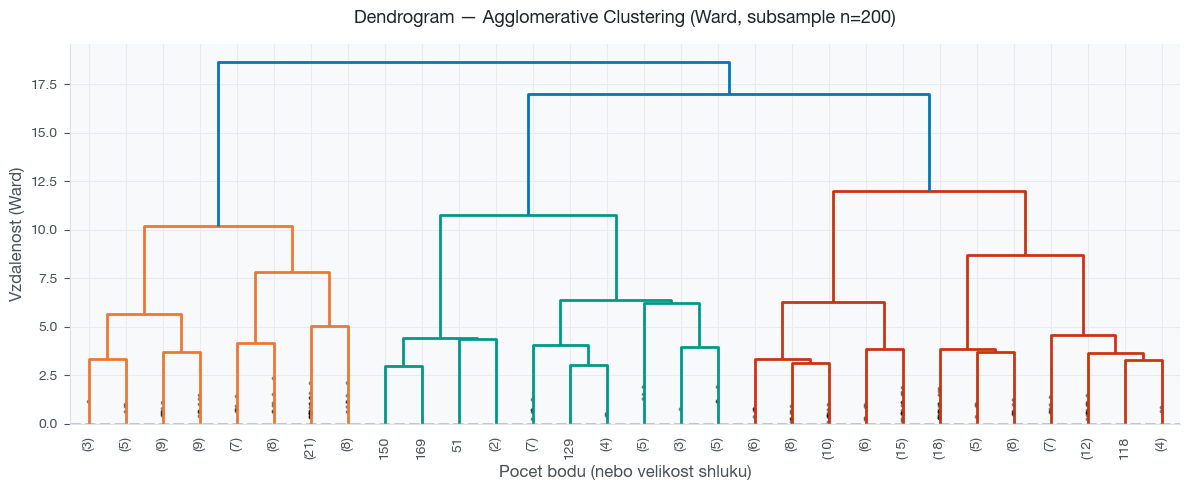

Horizontalni rez dendrogramem urci pocet shluku.
Pouzivame stejne OPTIMAL_K=3 jako u K-Means pro porovnatelnost.


In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Dendrogram pro vizualni volbu poctu shluku
# Pouzijeme subsample — dendrogram na celem datasetu je necitelny
sample_idx = X_cluster[cols_for_clustering].sample(n=min(200, len(X_cluster)), random_state=42).index
X_sample   = X_cluster.loc[sample_idx, cols_for_clustering]

linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(12, 5))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title('Dendrogram — Agglomerative Clustering (Ward, subsample n=200)', fontsize=13, pad=15)
plt.xlabel('Pocet bodu (nebo velikost shluku)')
plt.ylabel('Vzdalenost (Ward)')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Horizontalni rez dendrogramem urci pocet shluku.")
print(f"Pouzivame stejne OPTIMAL_K={OPTIMAL_K} jako u K-Means pro porovnatelnost.")

In [7]:
# Trenink Agglomerative s OPTIMAL_K — stejny pocet shluku jako K-Means pro primy srovnani
agglomerative_final = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agglomerative_final.fit_predict(X_cluster[cols_for_clustering])

X_cluster['Cluster_Agg'] = agg_labels

print(f"Rozlozeni shluku — Agglomerative (K={OPTIMAL_K}):")
print(X_cluster['Cluster_Agg'].value_counts().sort_index())

# Shoda s K-Means (adjusted Rand Index — 1.0 = identicky, 0.0 = nahodny)
from sklearn.metrics import adjusted_rand_score, silhouette_score
ari = adjusted_rand_score(X_cluster['Cluster'], X_cluster['Cluster_Agg'])
sil_kmeans = silhouette_score(X_cluster[cols_for_clustering], X_cluster['Cluster'])
sil_agg    = silhouette_score(X_cluster[cols_for_clustering], X_cluster['Cluster_Agg'])

print(f"\nPorovnani kvality shluku:")
print(f"  Silhouette K-Means:       {sil_kmeans:.3f}")
print(f"  Silhouette Agglomerative: {sil_agg:.3f}")
print(f"  Adjusted Rand Index (shoda mezi algoritmy): {ari:.3f}")
print(f"  (ARI blizko 1.0 = algoritmy se shoduji na stejnych shlucich)")

Rozlozeni shluku — Agglomerative (K=3):
Cluster_Agg
0    1512
1     355
2     588
Name: count, dtype: int64

Porovnani kvality shluku:
  Silhouette K-Means:       0.242
  Silhouette Agglomerative: 0.157
  Adjusted Rand Index (shoda mezi algoritmy): 0.326
  (ARI blizko 1.0 = algoritmy se shoduji na stejnych shlucich)


## Ulozeni vystupu

In [8]:
os.makedirs('../models',        exist_ok=True)
os.makedirs('../results',       exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

# Modely a scaler
joblib.dump(kmeans_final, '../models/kmeans_final.pkl')
joblib.dump(pca,          '../models/pca_2d.pkl')
joblib.dump(scaler,       '../models/cluster_scaler.pkl')
print("  models/kmeans_final.pkl")
print("  models/pca_2d.pkl")
print("  models/cluster_scaler.pkl")

# Data se stitky pro downstream notebooky
joblib.dump({
    'X_cluster':           X_cluster,
    'cols_for_clustering': cols_for_clustering,
    'OPTIMAL_K':           OPTIMAL_K,
    'scaler':              scaler,
    'y_sub':               y_sub,
}, '../data/processed/clustered_data.pkl')
print("  data/processed/clustered_data.pkl")

# Skore pro pripadne preplotovani bez retreningu
joblib.dump({'K_range': list(K_range),     'inertia': inertia},           '../results/elbow_scores.pkl')
joblib.dump({'K_range': list(K_range_sil), 'scores':  silhouette_scores}, '../results/silhouette_scores.pkl')
print("  results/elbow_scores.pkl")
print("  results/silhouette_scores.pkl")

print("\nVse ulozeno.")


  models/kmeans_final.pkl
  models/pca_2d.pkl
  models/cluster_scaler.pkl
  data/processed/clustered_data.pkl
  results/elbow_scores.pkl
  results/silhouette_scores.pkl

Vse ulozeno.
